# Capítulo 20 — Regularización y control de complejidad

En los capítulos anteriores aprendimos a detectar sobreajuste, evaluar mediante validación cruzada y ajustar hiperparámetros sin consultar repetidamente el test. Ahora usaremos esas herramientas para estudiar una estrategia concreta: **regularizar un modelo para controlar su complejidad**.

Comenzaremos con regresión lineal y compararemos una versión sin regularización con **Ridge** y **Lasso**. Después volveremos a la regresión logística para observar cómo las penalizaciones L1 y L2 también actúan en clasificación.

La idea central no será conseguir el menor error de entrenamiento, sino encontrar un equilibrio que favorezca la generalización.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar por qué limitar la complejidad puede mejorar la generalización;
- diferenciar las regularizaciones L1 y L2;
- reconocer el comportamiento de Ridge y Lasso;
- interpretar el efecto de `alpha` sobre los coeficientes;
- comprender por qué Lasso puede dejar coeficientes en cero;
- usar escalado y regularización dentro de un pipeline;
- elegir una intensidad mediante validación cruzada;
- interpretar el sentido inverso de `C` en regresión logística;
- reconocer cuándo una regularización excesiva produce subajuste;
- evaluar modelos elegidos sin usar el test durante la selección.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para construir y organizar los datos, Matplotlib para visualizar resultados y `scikit-learn` para crear pipelines, validar configuraciones y medir los modelos.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import (
    Lasso,
    LinearRegression,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    r2_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Algunas versiones recientes de scikit-learn anuncian cambios futuros
# en la sintaxis de LogisticRegression. Ocultamos solo esos avisos para
# mantener limpias las salidas didácticas.
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model",
)
warnings.filterwarnings(
    "ignore",
    message="Inconsistent values: penalty=.*",
)

plt.rcParams["figure.dpi"] = 110


## 2. Construir un problema de regresión con muchas variables

Crearemos un conjunto didáctico de viviendas. Ocho columnas representan características plausibles de una propiedad y otras treinta y seis serán variables de ruido.

Esta situación es deliberada: cuando hay muchas columnas en relación con la cantidad de filas, un modelo tiene más oportunidades de ajustar coincidencias que no se sostienen en datos nuevos.

> Los datos son sintéticos y se usan únicamente para estudiar el comportamiento de los modelos. Los precios no representan un mercado inmobiliario real.


In [2]:
rng = np.random.default_rng(12)
cantidad_viviendas = 160

superficie = np.clip(
    rng.normal(90, 25, cantidad_viviendas),
    35,
    170,
)
superficie_cubierta = (
    0.84 * superficie
    + rng.normal(0, 5, cantidad_viviendas)
)
ambientes = np.clip(
    np.round(
        superficie / 25
        + rng.normal(0, 0.7, cantidad_viviendas)
    ),
    1,
    8,
)
dormitorios = np.clip(
    ambientes - 1
    + rng.normal(0, 0.45, cantidad_viviendas),
    1,
    6,
)
antiguedad = rng.uniform(0, 50, cantidad_viviendas)
distancia = rng.uniform(0, 22, cantidad_viviendas)
calidad = rng.uniform(1, 10, cantidad_viviendas)
garage = rng.integers(0, 2, cantidad_viviendas)

X_reg = pd.DataFrame({
    "superficie_m2": superficie,
    "superficie_cubierta_m2": superficie_cubierta,
    "ambientes": ambientes,
    "dormitorios": dormitorios,
    "antiguedad_anios": antiguedad,
    "distancia_centro_km": distancia,
    "calidad_materiales": calidad,
    "garage": garage,
})

for numero in range(1, 37):
    X_reg[f"ruido_{numero:02d}"] = rng.normal(
        0,
        1,
        cantidad_viviendas,
    )

y_reg = (
    40_000
    + 950 * superficie
    + 9_000 * ambientes
    - 650 * antiguedad
    - 1_800 * distancia
    + 12_500 * calidad
    + 16_000 * garage
    + rng.normal(0, 23_000, cantidad_viviendas)
)
y_reg = pd.Series(y_reg, name="precio")

pd.DataFrame({
    "filas": [len(X_reg)],
    "variables_totales": [X_reg.shape[1]],
    "variables_con_señal": [8],
    "variables_de_ruido": [36],
})


,filas,variables_totales,variables_con_señal,variables_de_ruido
0,160,44,8,36


In [3]:
X_reg.head()


,superficie_m2,superficie_cubierta_m2,ambientes,dormitorios,antiguedad_anios,distancia_centro_km,calidad_materiales,garage,ruido_01,ruido_02,ruido_03,ruido_04,ruido_05,ruido_06,ruido_07,ruido_08,ruido_09,ruido_10,ruido_11,ruido_12,ruido_13,ruido_14,ruido_15,ruido_16,ruido_17,ruido_18,ruido_19,ruido_20,ruido_21,ruido_22,ruido_23,ruido_24,ruido_25,ruido_26,ruido_27,ruido_28,ruido_29,ruido_30,ruido_31,ruido_32,ruido_33,ruido_34,ruido_35,ruido_36
0,89.829331,73.511018,4.0,2.728436,25.178465,6.784538,3.622089,1,0.406702,0.455896,-0.133733,-0.596170,0.279606,-0.255038,0.509693,1.486337,0.034425,-0.665022,0.495078,-0.118910,0.007791,0.099034,-0.712728,-2.719620,0.375631,-0.737557,-0.859702,-0.362265,-1.655873,-0.229366,1.403282,-0.791426,1.035355,-2.657214,-0.599108,-0.328645,-0.672866,0.128178,-1.711488,0.876625,-0.822821,1.055893,0.357546,0.536675
1,116.153582,93.078956,5.0,3.988771,24.806186,3.673462,4.938088,0,0.495415,1.319474,-0.107842,-1.962854,1.448119,0.025818,-1.019980,-1.357156,-1.094870,-0.595672,-0.616241,-1.050093,-0.843459,-0.147090,1.455997,-0.560643,1.368680,1.034797,1.365142,1.350203,0.798670,0.689617,0.476153,1.180384,0.635049,0.513627,-0.240921,-0.347084,0.818696,0.302035,-0.608052,0.656693,0.439217,-0.851304,0.739030,0.396918
2,108.539711,86.115716,5.0,3.748875,49.786264,20.720251,7.772032,0,0.302703,-0.250659,0.580574,0.132804,-0.020860,0.234664,0.186734,-0.812525,1.233183,0.369414,-0.630903,1.044635,0.593046,1.235768,-0.616954,1.001590,0.348788,-0.105261,0.413177,0.723605,-1.129339,1.231435,-0.108529,0.938056,-0.320773,-1.809482,-1.206437,-1.795629,0.099858,1.113365,-0.428962,0.254174,0.102069,1.293312,-1.363205,-0.314503
3,108.098914,91.308193,4.0,3.742819,37.009076,14.759900,3.290587,1,0.909690,-0.229142,-1.485110,0.791999,-0.297012,1.055022,-1.068158,-0.166162,-1.231382,-1.703263,0.629778,0.231079,0.115585,-0.941913,0.371940,-0.974855,-0.136729,-1.258055,1.055398,1.238931,-0.418015,-0.582866,-0.283811,0.029653,0.034691,-0.507747,0.413899,0.455913,-0.203304,-0.797451,0.307441,-1.139532,1.240188,-0.405258,0.391271,0.039876
4,130.469406,111.171050,5.0,4.263102,26.482243,13.263136,4.594412,1,-0.530950,-0.671261,0.010916,0.678486,-1.024158,-0.871792,-2.232120,-0.023932,0.012326,-0.931060,-1.782645,1.660782,0.338201,-0.025825,0.707404,0.214843,0.145962,2.128419,0.304333,0.205717,0.174831,0.090093,0.262946,1.680284,0.417000,0.331090,-0.153618,-2.634255,-0.331487,1.044702,0.461139,0.763715,1.762941,1.108518,-0.137051,-1.249796


Algunas variables con señal también están relacionadas entre sí. Por ejemplo, la superficie total, la superficie cubierta, los ambientes y los dormitorios contienen información parcialmente superpuesta. Esta correlación puede volver inestables los coeficientes de una regresión lineal sin regularización.


In [4]:
variables_relacionadas = [
    "superficie_m2",
    "superficie_cubierta_m2",
    "ambientes",
    "dormitorios",
]

X_reg[variables_relacionadas].corr().round(2)


,superficie_m2,superficie_cubierta_m2,ambientes,dormitorios
superficie_m2,1.00,0.97,0.78,0.73
superficie_cubierta_m2,0.97,1.00,0.77,0.72
ambientes,0.78,0.77,1.00,0.93
dormitorios,0.73,0.72,0.93,1.00


## 3. Reservar el test final

Separaremos un 20% de los datos. La validación cruzada y la elección de `alpha` se realizarán únicamente con el conjunto de desarrollo.


In [5]:
X_reg_desarrollo, X_reg_test, y_reg_desarrollo, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=20,
    )
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [
        len(X_reg_desarrollo),
        len(X_reg_test),
    ],
    "variables": [
        X_reg_desarrollo.shape[1],
        X_reg_test.shape[1],
    ],
})


,conjunto,filas,variables
0,Desarrollo,128,44
1,Prueba final,32,44


El test permanecerá sin consultar hasta que hayamos elegido las configuraciones. Si usáramos sus resultados para cambiar `alpha`, dejaría de ser una prueba independiente.


## 4. Por qué escalamos antes de regularizar

Ridge y Lasso penalizan el tamaño de los coeficientes. Si una variable está medida en metros cuadrados y otra toma valores entre cero y uno, sus escalas son muy diferentes.

Usaremos `StandardScaler` dentro de cada pipeline. Así, el escalado se aprenderá nuevamente dentro de cada fold y la penalización podrá actuar sobre variables comparables.


In [6]:
pipeline_lineal = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LinearRegression()),
])

pipeline_ridge = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", Ridge()),
])

pipeline_lasso = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", Lasso(max_iter=50_000)),
])

pipeline_ridge


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('escala', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


La regresión lineal servirá como referencia sin penalización. Ridge aplica L2 y tiende a reducir los coeficientes sin llevarlos a cero. Lasso aplica L1 y puede anular algunos.

También existe **Elastic Net**, que combina L1 y L2. En este cuaderno no la desarrollaremos porque primero necesitamos observar con claridad el efecto particular de cada penalización.


## 5. Comparar intensidades de regularización

En Ridge y Lasso, `alpha` controla la intensidad:

```text
alpha pequeño → regularización débil
alpha grande  → regularización fuerte
```

Probaremos escalas distintas porque Ridge y Lasso no reaccionan de la misma manera a los mismos valores numéricos. La métrica será MAE y usaremos exactamente los mismos cinco folds.


In [7]:
cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

alphas_ridge = np.logspace(-3, 4, 8)
alphas_lasso = [
    1,
    10,
    100,
    300,
    1_000,
    3_000,
    10_000,
    30_000,
]

busqueda_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid={"modelo__alpha": alphas_ridge},
    cv=cv_reg,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
)

busqueda_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid={"modelo__alpha": alphas_lasso},
    cv=cv_reg,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
)

busqueda_ridge.fit(X_reg_desarrollo, y_reg_desarrollo)
_ = busqueda_lasso.fit(
    X_reg_desarrollo,
    y_reg_desarrollo,
)


In [8]:
pd.DataFrame({
    "modelo": ["Ridge", "Lasso"],
    "mejor_alpha": [
        busqueda_ridge.best_params_["modelo__alpha"],
        busqueda_lasso.best_params_["modelo__alpha"],
    ],
    "MAE_promedio_cv": [
        -busqueda_ridge.best_score_,
        -busqueda_lasso.best_score_,
    ],
}).round(2)


,modelo,mejor_alpha,MAE_promedio_cv
0,Ridge,10.0,23735.52
1,Lasso,3000.0,20930.29


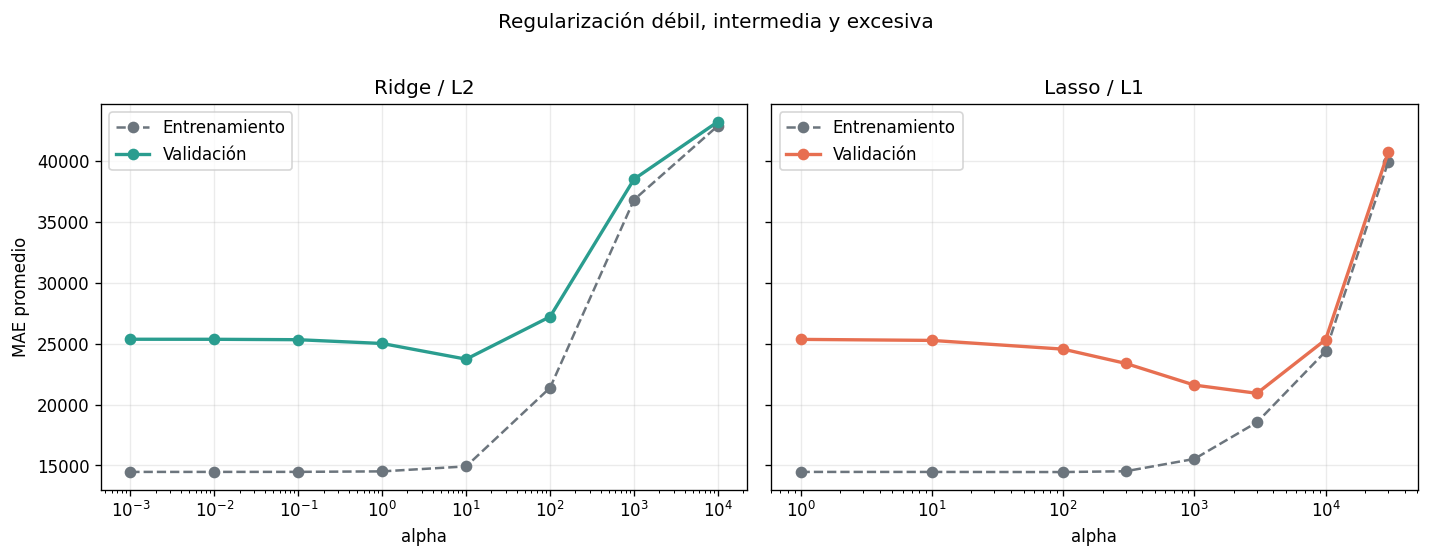

In [9]:
resultados_ridge = pd.DataFrame(
    busqueda_ridge.cv_results_
)
resultados_lasso = pd.DataFrame(
    busqueda_lasso.cv_results_
)

fig, ejes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    sharey=True,
)

for ax, resultados, titulo, color in [
    (ejes[0], resultados_ridge, "Ridge / L2", "#2A9D8F"),
    (ejes[1], resultados_lasso, "Lasso / L1", "#E76F51"),
]:
    alphas = resultados["param_modelo__alpha"].astype(float)
    mae_train = -resultados["mean_train_score"]
    mae_validacion = -resultados["mean_test_score"]

    ax.plot(
        alphas,
        mae_train,
        "o--",
        color="#6C757D",
        label="Entrenamiento",
    )
    ax.plot(
        alphas,
        mae_validacion,
        "o-",
        color=color,
        linewidth=2,
        label="Validación",
    )
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_title(titulo)
    ax.grid(alpha=0.25)
    ax.legend()

ejes[0].set_ylabel("MAE promedio")
fig.suptitle(
    "Regularización débil, intermedia y excesiva",
    y=1.02,
)
plt.tight_layout()
plt.show()


La regularización intermedia reduce el MAE de validación respecto de configuraciones muy débiles. Cuando `alpha` crece demasiado, el error aumenta tanto en entrenamiento como en validación: el modelo quedó tan restringido que comenzó a subajustar.

También observamos que el menor error de entrenamiento no identifica por sí solo la mejor configuración. La selección se basa en los folds de validación.


## 6. Observar qué ocurre con los coeficientes

Para comparar coeficientes de manera coherente, ajustaremos modelos sobre variables estandarizadas. Analizaremos ocho variables con señal y ocho variables de ruido; el resto se mantiene en el entrenamiento, pero no se dibuja para evitar un gráfico ilegible.


In [10]:
variables_para_grafico = (
    list(X_reg.columns[:8])
    + list(X_reg.columns[8:16])
)

def coeficientes_por_alpha(modelo, alphas):
    filas = []

    for alpha in alphas:
        pipeline = Pipeline(steps=[
            ("escala", StandardScaler()),
            ("modelo", modelo(alpha=alpha)),
        ])
        pipeline.fit(X_reg_desarrollo, y_reg_desarrollo)

        coeficientes = (
            pipeline.named_steps["modelo"].coef_
        )
        filas.append(
            pd.Series(
                coeficientes,
                index=X_reg.columns,
                name=float(alpha),
            )
        )

    return pd.DataFrame(filas)


coef_ridge = coeficientes_por_alpha(
    Ridge,
    alphas_ridge,
)
coef_lasso = coeficientes_por_alpha(
    lambda alpha: Lasso(
        alpha=alpha,
        max_iter=50_000,
    ),
    alphas_lasso,
)


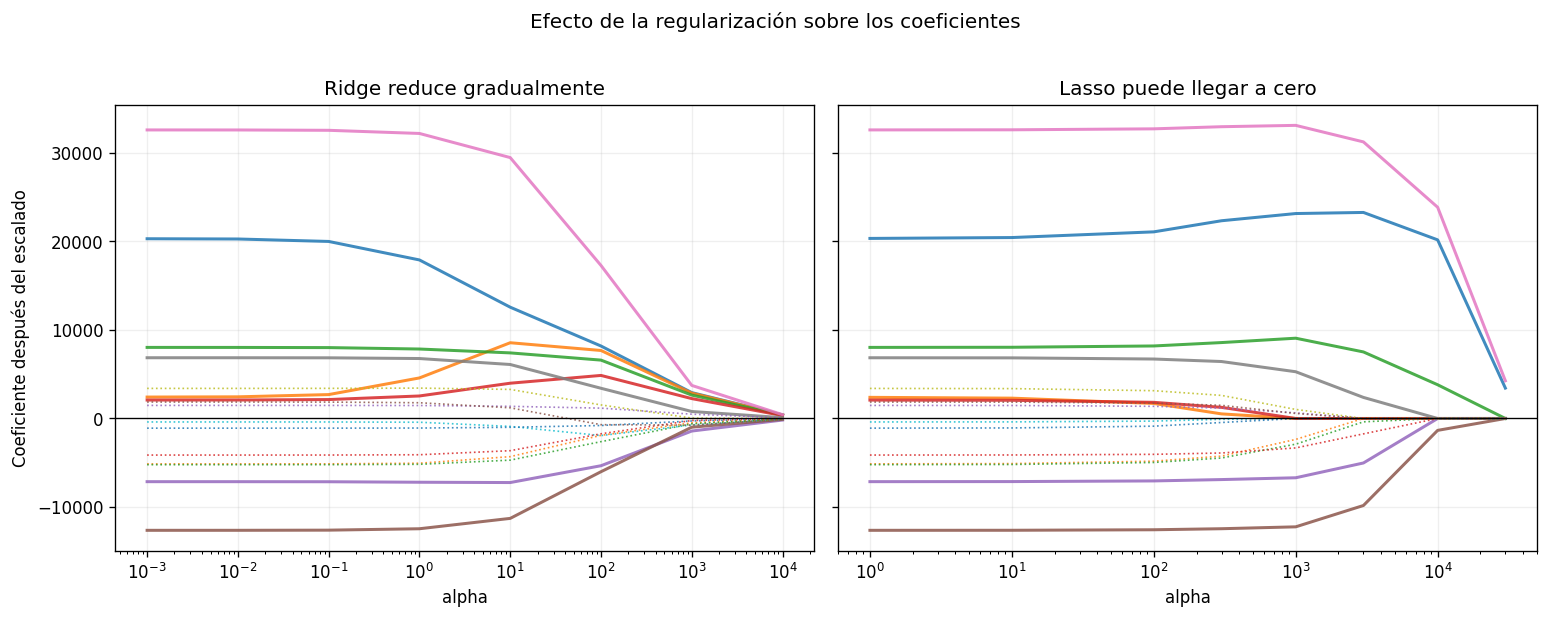

In [11]:
fig, ejes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharey=True,
)

for variable in variables_para_grafico:
    estilo = "-" if not variable.startswith("ruido") else ":"
    grosor = 1.8 if estilo == "-" else 1.0

    ejes[0].plot(
        coef_ridge.index,
        coef_ridge[variable],
        linestyle=estilo,
        linewidth=grosor,
        alpha=0.85,
    )
    ejes[1].plot(
        coef_lasso.index,
        coef_lasso[variable],
        linestyle=estilo,
        linewidth=grosor,
        alpha=0.85,
    )

for ax, titulo in zip(
    ejes,
    ["Ridge reduce gradualmente", "Lasso puede llegar a cero"],
):
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_title(titulo)
    ax.grid(alpha=0.2)

ejes[0].set_ylabel("Coeficiente después del escalado")
fig.suptitle(
    "Efecto de la regularización sobre los coeficientes",
    y=1.02,
)
plt.tight_layout()
plt.show()


En Ridge, los coeficientes se acercan gradualmente a cero a medida que aumenta `alpha`, pero permanecen activos. En Lasso, varias trayectorias llegan exactamente a cero.

Las líneas punteadas representan variables de ruido. El gráfico permite comprender la tendencia general, pero no demuestra que una columna sea importante o irrelevante en sentido causal.


In [12]:
modelo_ridge_elegido = busqueda_ridge.best_estimator_
modelo_lasso_elegido = busqueda_lasso.best_estimator_

tabla_coeficientes = pd.DataFrame({
    "variable": X_reg.columns,
    "Ridge": (
        modelo_ridge_elegido
        .named_steps["modelo"]
        .coef_
    ),
    "Lasso": (
        modelo_lasso_elegido
        .named_steps["modelo"]
        .coef_
    ),
})
tabla_coeficientes["Lasso_es_cero"] = np.isclose(
    tabla_coeficientes["Lasso"],
    0,
)

resumen_coeficientes = pd.DataFrame({
    "modelo": ["Ridge", "Lasso"],
    "coeficientes_activos": [
        np.count_nonzero(
            ~np.isclose(tabla_coeficientes["Ridge"], 0)
        ),
        np.count_nonzero(
            ~tabla_coeficientes["Lasso_es_cero"]
        ),
    ],
    "coeficientes_en_cero": [
        np.count_nonzero(
            np.isclose(tabla_coeficientes["Ridge"], 0)
        ),
        tabla_coeficientes["Lasso_es_cero"].sum(),
    ],
})

resumen_coeficientes


,modelo,coeficientes_activos,coeficientes_en_cero
0,Ridge,44,0
1,Lasso,13,31


In [13]:
tabla_coeficientes.sort_values(
    "Lasso",
    key=lambda serie: serie.abs(),
    ascending=False,
).head(14).round(2)


,variable,Ridge,Lasso,Lasso_es_cero
6,calidad_materiales,29468.46,31239.20,False
0,superficie_m2,12570.66,23271.40,False
5,distancia_centro_km,-11282.97,-9827.19,False
2,ambientes,7409.05,7516.50,False
4,antiguedad_anios,-7235.87,-5024.60,False
7,garage,6098.50,2379.90,False
13,ruido_06,-3637.40,-1737.92,False
42,ruido_35,-7449.46,-1123.13,False
12,ruido_05,-4704.59,-377.38,False
36,ruido_29,-927.64,-313.28,False


Lasso produce un modelo más compacto, pero un coeficiente cero significa solamente que esa variable no fue usada por **este modelo, con estos datos y este `alpha`**. Si varias columnas están correlacionadas, Lasso puede conservar una y anular otra aunque ambas contengan información parecida.


## 7. Comparar los modelos elegidos

Antes de mirar el test, calcularemos la referencia de validación cruzada de la regresión lineal sin regularización. Ridge y Lasso ya fueron elegidos exclusivamente con el conjunto de desarrollo.


In [14]:
mae_cv_lineal = -cross_val_score(
    pipeline_lineal,
    X_reg_desarrollo,
    y_reg_desarrollo,
    cv=cv_reg,
    scoring="neg_mean_absolute_error",
).mean()

comparacion_cv_reg = pd.DataFrame({
    "modelo": [
        "Regresión lineal",
        "Ridge elegido",
        "Lasso elegido",
    ],
    "MAE_promedio_cv": [
        mae_cv_lineal,
        -busqueda_ridge.best_score_,
        -busqueda_lasso.best_score_,
    ],
})

comparacion_cv_reg.round(2)


,modelo,MAE_promedio_cv
0,Regresión lineal,25374.56
1,Ridge elegido,23735.52
2,Lasso elegido,20930.29


Ahora sí ajustaremos la referencia con todo el conjunto de desarrollo y evaluaremos una sola vez los tres modelos sobre el test reservado. Esta comparación es legítima porque las decisiones anteriores no se tomaron mirando esos datos.


In [15]:
pipeline_lineal.fit(
    X_reg_desarrollo,
    y_reg_desarrollo,
)

modelos_reg_finales = {
    "Regresión lineal": pipeline_lineal,
    "Ridge": modelo_ridge_elegido,
    "Lasso": modelo_lasso_elegido,
}

filas_evaluacion_reg = []
predicciones_reg = {}

for nombre, modelo in modelos_reg_finales.items():
    pred_train = modelo.predict(X_reg_desarrollo)
    pred_test = modelo.predict(X_reg_test)
    predicciones_reg[nombre] = pred_test

    filas_evaluacion_reg.append({
        "modelo": nombre,
        "MAE_entrenamiento": mean_absolute_error(
            y_reg_desarrollo,
            pred_train,
        ),
        "MAE_test": mean_absolute_error(
            y_reg_test,
            pred_test,
        ),
        "R2_test": r2_score(
            y_reg_test,
            pred_test,
        ),
    })

evaluacion_reg = pd.DataFrame(
    filas_evaluacion_reg
)
evaluacion_reg.round(3)


,modelo,MAE_entrenamiento,MAE_test,R2_test
0,Regresión lineal,15415.837,23672.196,0.653
1,Ridge,15558.638,21379.341,0.712
2,Lasso,18900.782,14381.582,0.850


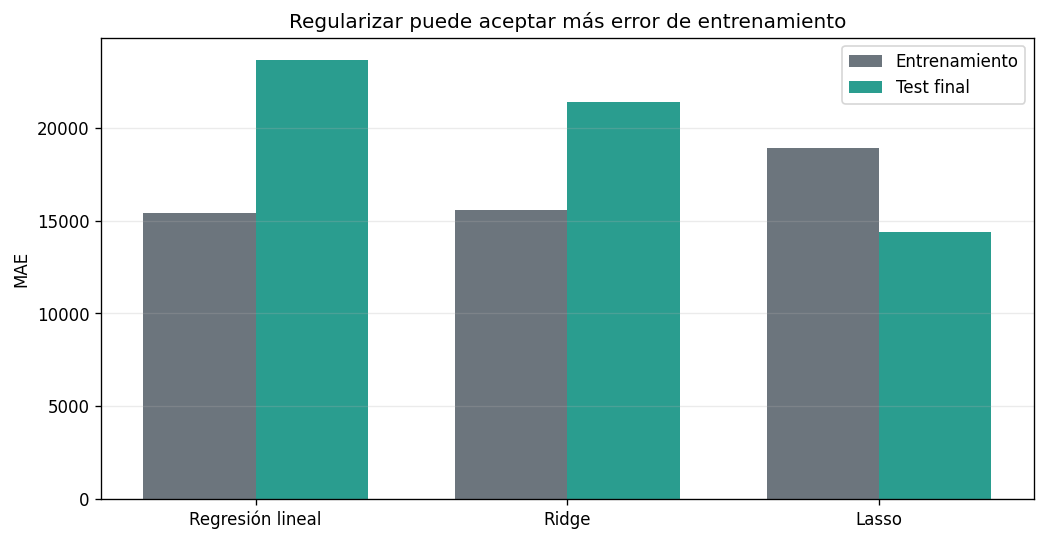

In [16]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))

x = np.arange(len(evaluacion_reg))
ancho = 0.36

ax.bar(
    x - ancho / 2,
    evaluacion_reg["MAE_entrenamiento"],
    width=ancho,
    color="#6C757D",
    label="Entrenamiento",
)
ax.bar(
    x + ancho / 2,
    evaluacion_reg["MAE_test"],
    width=ancho,
    color="#2A9D8F",
    label="Test final",
)

ax.set_xticks(x)
ax.set_xticklabels(evaluacion_reg["modelo"])
ax.set_ylabel("MAE")
ax.set_title(
    "Regularizar puede aceptar más error de entrenamiento"
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


La regresión lineal consigue el menor MAE de entrenamiento, pero generaliza peor que los modelos regularizados. Lasso acepta un error algo mayor sobre los datos conocidos y obtiene el menor MAE en el test.

Este resultado ilustra la motivación de la regularización. No demuestra que Lasso sea siempre superior: en otro dataset, otra división o con otra relación entre variables, Ridge o la regresión lineal podrían ser opciones adecuadas.


## 8. Regularización en regresión logística

La regresión logística clasifica, pero también aprende coeficientes. Por eso puede usar penalizaciones L1 y L2.

Continuaremos con **Breast Cancer Wisconsin**, ya utilizado en capítulos anteriores, y mantendremos la convención:

- `0`: caso benigno;
- `1`: caso maligno.

> El dataset se utiliza exclusivamente con fines educativos. Estos modelos no constituyen herramientas médicas ni deben usarse para tomar decisiones clínicas.


In [17]:
datos_medicos = load_breast_cancer(as_frame=True)

X_clf = datos_medicos.data
y_clf = 1 - datos_medicos.target
y_clf.name = "caso_maligno"

X_clf_desarrollo, X_clf_test, y_clf_desarrollo, y_clf_test = (
    train_test_split(
        X_clf,
        y_clf,
        test_size=0.20,
        random_state=20,
        stratify=y_clf,
    )
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [
        len(X_clf_desarrollo),
        len(X_clf_test),
    ],
    "proporcion_malignos": [
        y_clf_desarrollo.mean(),
        y_clf_test.mean(),
    ],
}).round(3)


,conjunto,filas,proporcion_malignos
0,Desarrollo,455,0.374
1,Prueba final,114,0.368


En `LogisticRegression`, la intensidad se controla con `C`, que funciona al revés que `alpha`:

```text
C pequeño → regularización más fuerte
C grande  → regularización más débil
```

Compararemos L2 y L1 mediante F1-score. Usaremos `solver="liblinear"` porque es compatible con ambas penalizaciones en un problema binario.


In [18]:
cv_clf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)
valores_C = [0.001, 0.01, 0.1, 1, 10, 100]

pipeline_logistica_l2 = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5_000,
    )),
])

pipeline_logistica_l1 = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5_000,
    )),
])

busqueda_logistica_l2 = GridSearchCV(
    estimator=pipeline_logistica_l2,
    param_grid={"modelo__C": valores_C},
    cv=cv_clf,
    scoring="f1",
    return_train_score=True,
)
busqueda_logistica_l1 = GridSearchCV(
    estimator=pipeline_logistica_l1,
    param_grid={"modelo__C": valores_C},
    cv=cv_clf,
    scoring="f1",
    return_train_score=True,
)

busqueda_logistica_l2.fit(
    X_clf_desarrollo,
    y_clf_desarrollo,
)
_ = busqueda_logistica_l1.fit(
    X_clf_desarrollo,
    y_clf_desarrollo,
)


In [19]:
resultados_log_l2 = pd.DataFrame(
    busqueda_logistica_l2.cv_results_
)
resultados_log_l1 = pd.DataFrame(
    busqueda_logistica_l1.cv_results_
)

pd.DataFrame({
    "penalizacion": ["L2", "L1"],
    "mejor_C": [
        busqueda_logistica_l2.best_params_["modelo__C"],
        busqueda_logistica_l1.best_params_["modelo__C"],
    ],
    "F1_promedio_cv": [
        busqueda_logistica_l2.best_score_,
        busqueda_logistica_l1.best_score_,
    ],
}).round(4)


,penalizacion,mejor_C,F1_promedio_cv
0,L2,1,0.9793
1,L1,1,0.9791


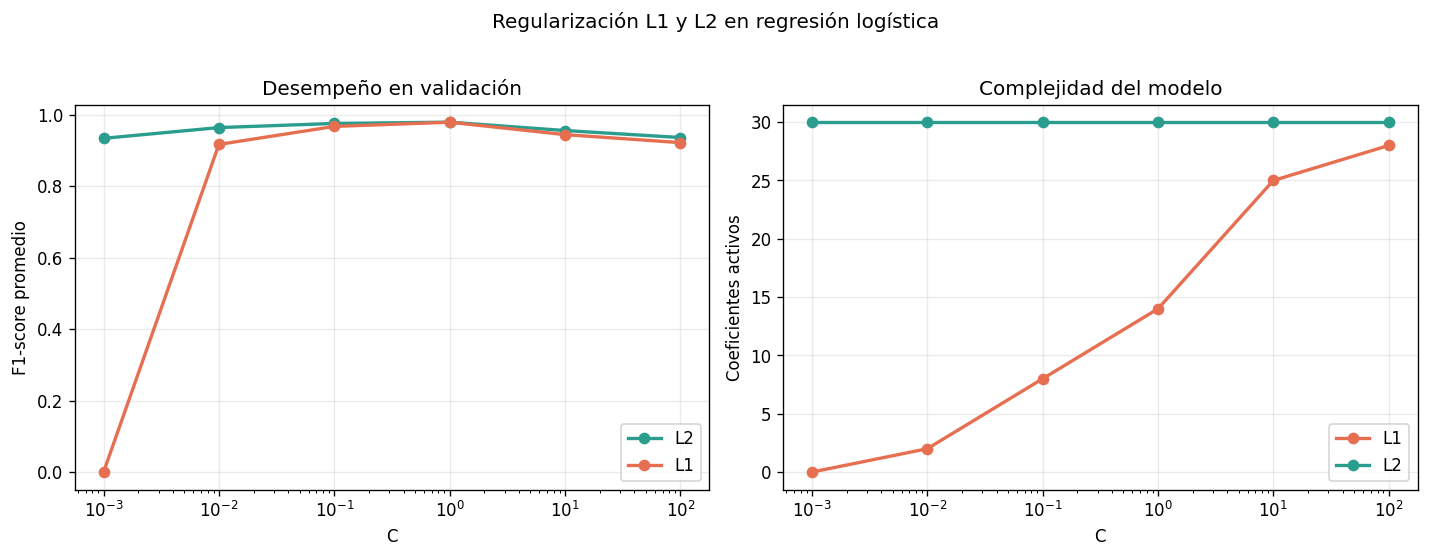

In [20]:
filas_coef_log = []

for penalizacion, resultados, busqueda in [
    ("L2", resultados_log_l2, busqueda_logistica_l2),
    ("L1", resultados_log_l1, busqueda_logistica_l1),
]:
    for C in valores_C:
        modelo = busqueda.estimator.set_params(
            modelo__C=C
        )
        modelo.fit(X_clf_desarrollo, y_clf_desarrollo)
        coeficientes = (
            modelo.named_steps["modelo"].coef_.ravel()
        )

        filas_coef_log.append({
            "penalizacion": penalizacion,
            "C": C,
            "coeficientes_activos": np.count_nonzero(
                ~np.isclose(coeficientes, 0)
            ),
        })

coeficientes_log_por_C = pd.DataFrame(
    filas_coef_log
)

fig, ejes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

for resultados, etiqueta, color in [
    (resultados_log_l2, "L2", "#2A9D8F"),
    (resultados_log_l1, "L1", "#E76F51"),
]:
    ejes[0].plot(
        resultados["param_modelo__C"].astype(float),
        resultados["mean_test_score"],
        "o-",
        color=color,
        linewidth=2,
        label=etiqueta,
    )

for penalizacion, grupo in coeficientes_log_por_C.groupby(
    "penalizacion"
):
    color = "#2A9D8F" if penalizacion == "L2" else "#E76F51"
    ejes[1].plot(
        grupo["C"],
        grupo["coeficientes_activos"],
        "o-",
        color=color,
        linewidth=2,
        label=penalizacion,
    )

ejes[0].set_xscale("log")
ejes[0].set_xlabel("C")
ejes[0].set_ylabel("F1-score promedio")
ejes[0].set_title("Desempeño en validación")
ejes[0].grid(alpha=0.25)
ejes[0].legend()

ejes[1].set_xscale("log")
ejes[1].set_xlabel("C")
ejes[1].set_ylabel("Coeficientes activos")
ejes[1].set_title("Complejidad del modelo")
ejes[1].grid(alpha=0.25)
ejes[1].legend()

fig.suptitle(
    "Regularización L1 y L2 en regresión logística",
    y=1.02,
)
plt.tight_layout()
plt.show()


Con valores muy pequeños de `C`, la regularización es tan fuerte que el desempeño cae. Al aumentar `C`, el modelo gana libertad y mejora hasta alcanzar una zona intermedia. Con valores muy grandes, la brecha entre entrenamiento y validación vuelve a crecer.

L2 mantiene activos los treinta coeficientes. L1, en cambio, utiliza pocos cuando la regularización es fuerte y agrega más a medida que `C` aumenta.


## 9. Comparar los coeficientes elegidos

Observaremos los coeficientes de las mejores configuraciones encontradas por validación cruzada. Como las variables fueron estandarizadas, sus magnitudes pueden compararse dentro de cada modelo con mayor sentido.


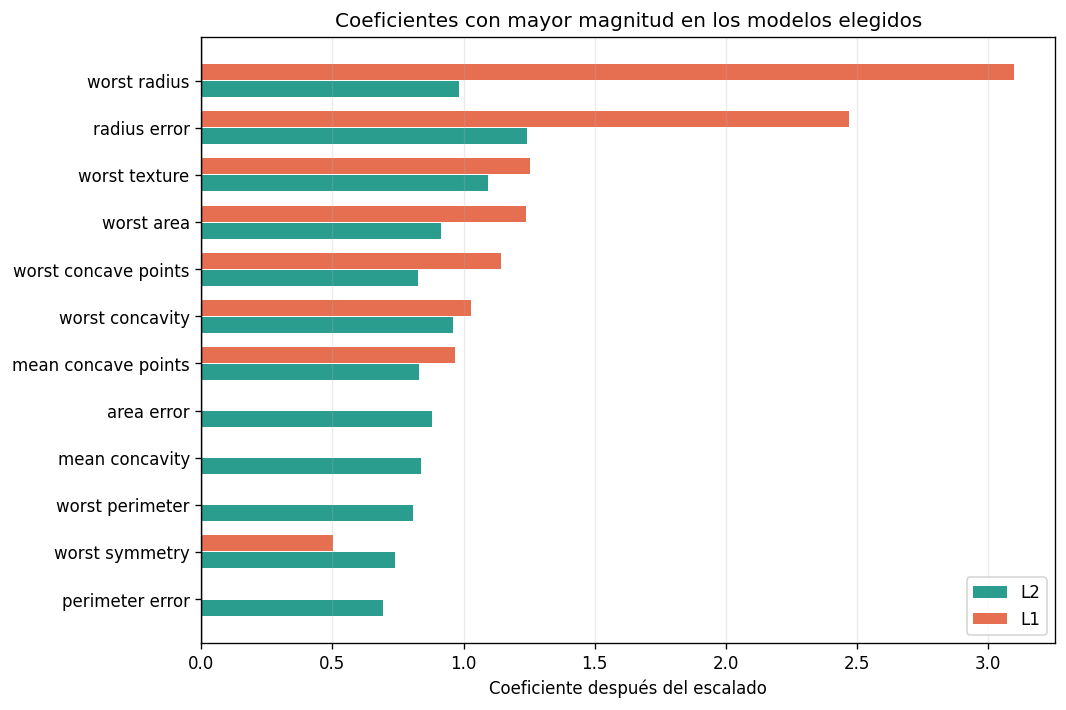

In [21]:
mejor_log_l2 = busqueda_logistica_l2.best_estimator_
mejor_log_l1 = busqueda_logistica_l1.best_estimator_

coef_log_elegidos = pd.DataFrame({
    "variable": X_clf.columns,
    "L2": (
        mejor_log_l2
        .named_steps["modelo"]
        .coef_
        .ravel()
    ),
    "L1": (
        mejor_log_l1
        .named_steps["modelo"]
        .coef_
        .ravel()
    ),
})

coef_log_elegidos["magnitud_maxima"] = (
    coef_log_elegidos[["L1", "L2"]]
    .abs()
    .max(axis=1)
)
coef_log_mostrados = (
    coef_log_elegidos
    .nlargest(12, "magnitud_maxima")
    .sort_values("magnitud_maxima")
)

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(coef_log_mostrados))

ax.barh(
    y_pos - 0.18,
    coef_log_mostrados["L2"],
    height=0.34,
    color="#2A9D8F",
    label="L2",
)
ax.barh(
    y_pos + 0.18,
    coef_log_mostrados["L1"],
    height=0.34,
    color="#E76F51",
    label="L1",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_log_mostrados["variable"])
ax.set_xlabel("Coeficiente después del escalado")
ax.set_title(
    "Coeficientes con mayor magnitud en los modelos elegidos"
)
ax.grid(axis="x", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
pd.DataFrame({
    "penalizacion": ["L2", "L1"],
    "coeficientes_activos": [
        np.count_nonzero(
            ~np.isclose(
                coef_log_elegidos["L2"],
                0,
            )
        ),
        np.count_nonzero(
            ~np.isclose(
                coef_log_elegidos["L1"],
                0,
            )
        ),
    ],
    "coeficientes_en_cero": [
        np.count_nonzero(
            np.isclose(
                coef_log_elegidos["L2"],
                0,
            )
        ),
        np.count_nonzero(
            np.isclose(
                coef_log_elegidos["L1"],
                0,
            )
        ),
    ],
})


,penalizacion,coeficientes_activos,coeficientes_en_cero
0,L2,30,0
1,L1,14,16


L1 logra una representación más compacta. Sin embargo, no debemos convertir esta selección en una explicación causal ni asumir que las variables anuladas carecen de relación con el problema. El resultado depende de la muestra, las otras columnas, el escalado, `C` y la métrica utilizada.


## 10. Evaluar la clasificación sobre el test final

Las dos configuraciones fueron elegidas mediante validación cruzada dentro del conjunto de desarrollo. Ahora consultaremos el test reservado una sola vez.


In [23]:
filas_evaluacion_clf = []

for nombre, modelo, f1_cv in [
    (
        "Logística L2",
        mejor_log_l2,
        busqueda_logistica_l2.best_score_,
    ),
    (
        "Logística L1",
        mejor_log_l1,
        busqueda_logistica_l1.best_score_,
    ),
]:
    pred_test = modelo.predict(X_clf_test)

    filas_evaluacion_clf.append({
        "modelo": nombre,
        "F1_promedio_cv": f1_cv,
        "accuracy_test": accuracy_score(
            y_clf_test,
            pred_test,
        ),
        "recall_test": recall_score(
            y_clf_test,
            pred_test,
        ),
        "F1_test": f1_score(
            y_clf_test,
            pred_test,
        ),
    })

evaluacion_clf = pd.DataFrame(
    filas_evaluacion_clf
)
evaluacion_clf.round(4)


,modelo,F1_promedio_cv,accuracy_test,recall_test,F1_test
0,Logística L2,0.9793,0.9825,0.9762,0.9762
1,Logística L1,0.9791,0.9825,0.9762,0.9762


Ambas penalizaciones producen resultados similares en el test, aunque L1 utiliza menos coeficientes. Esto no obliga a elegir L1: si la diferencia predictiva es pequeña, también podemos considerar estabilidad, simplicidad e interpretabilidad.

La conclusión sigue siendo prudente. Se trata de una comparación ilustrativa sobre una división final; no de una garantía clínica ni de una superioridad universal.


## 11. Cuándo ayuda y cuándo puede perjudicar

La regularización suele ayudar cuando hay muchas variables, ruido, columnas correlacionadas o una brecha importante entre entrenamiento y validación. Puede perjudicar cuando se aplica con demasiada intensidad o cuando el modelo ya está subajustando.

Antes de aumentar la penalización conviene observar el patrón:

| Entrenamiento | Validación | Lectura posible |
|---|---|---|
| Muy bueno | Bastante peor | Puede haber sobreajuste; regularizar podría ayudar |
| Malo | Malo | Puede haber subajuste; regularizar más probablemente perjudique |
| Algo menor | Mejor que antes | La regularización puede estar mejorando la generalización |

Regularizar tampoco corrige fuga de datos, etiquetas mal definidas, variables inválidas, datos no representativos ni falta de señal.


## 12. Actividad breve

La siguiente celda permite explorar Ridge con una lista pequeña de valores. Modificá `alphas_actividad` y observá cómo cambian el MAE de validación y el tamaño total de los coeficientes. El test no participa.


In [24]:
alphas_actividad = [0.1, 1, 10, 100, 1_000]
filas_actividad = []

for alpha in alphas_actividad:
    modelo = Pipeline(steps=[
        ("escala", StandardScaler()),
        ("modelo", Ridge(alpha=alpha)),
    ])

    scores = cross_val_score(
        modelo,
        X_reg_desarrollo,
        y_reg_desarrollo,
        cv=cv_reg,
        scoring="neg_mean_absolute_error",
    )

    modelo.fit(X_reg_desarrollo, y_reg_desarrollo)
    norma_coeficientes = np.linalg.norm(
        modelo.named_steps["modelo"].coef_
    )

    filas_actividad.append({
        "alpha": alpha,
        "MAE_promedio_cv": -scores.mean(),
        "desviacion_MAE": scores.std(),
        "norma_coeficientes": norma_coeficientes,
    })

pd.DataFrame(filas_actividad).round(2)


,alpha,MAE_promedio_cv,desviacion_MAE,norma_coeficientes
0,0.1,25337.10,3651.04,46044.50
1,1.0,25025.40,3694.20,44969.54
2,10.0,23735.52,4004.84,40698.47
3,100.0,27226.94,4241.54,25839.21
4,1000.0,38536.37,4724.58,7378.05


Podés continuar la actividad de esta manera:

1. agregá un valor de `alpha` más pequeño y otro más grande;
2. identificá cuándo la reducción de coeficientes empieza a perjudicar el MAE;
3. repetí la exploración con Lasso y contá cuántos coeficientes quedan en cero;
4. explicá por qué no corresponde elegir una configuración mirando el test.


## 13. Síntesis

En este cuaderno:

- relacionamos regularización, complejidad y generalización;
- construimos un problema con muchas variables y columnas de ruido;
- usamos `StandardScaler` dentro de pipelines;
- comparamos regresión lineal, Ridge y Lasso;
- interpretamos `alpha` como intensidad de regularización;
- comprobamos que una penalización excesiva puede producir subajuste;
- observamos cómo Ridge reduce coeficientes de forma gradual;
- observamos cómo Lasso puede dejar coeficientes en cero;
- elegimos configuraciones mediante validación cruzada;
- reservamos el test para la evaluación final;
- aplicamos regularización L1 y L2 a regresión logística;
- interpretamos el sentido inverso de `C`;
- distinguimos selección predictiva de explicación causal.

Regularizar no significa hacer el modelo lo más simple posible. Significa limitar su flexibilidad lo suficiente para evitar que persiga detalles accidentales, sin impedir que aprenda los patrones útiles.


## Para pensar

1. ¿Por qué el mejor modelo de entrenamiento puede no ser el que mejor generaliza?
2. ¿Qué diferencia práctica observaste entre Ridge y Lasso sobre los coeficientes?
3. ¿Por qué conviene escalar las variables dentro del pipeline antes de regularizar?
4. ¿Cómo cambia la intensidad al aumentar `alpha` y cómo cambia al aumentar `C`?
5. ¿Por qué un coeficiente igual a cero no demuestra que una variable sea irrelevante en el mundo real?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
